# Iniesta vs Zidane: Phase 4 Analysis

Comprehensive comparison across 6 pillars: Attack, Possession, Defense, Clutch, Consistency, Recognition

**Data sources**: Wikipedia, StatsBomb, Transfermarkt
**Color scheme**: Iniesta = #A50044 (Barcelona red), Zidane = #FEBE10 (Real Madrid gold)

In [1]:
import os
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from math import pi
from pathlib import Path

print(f'Python {sys.version}\nPandas {pd.__version__}\nMatplotlib {matplotlib.__version__}')
print(f'NumPy {np.__version__}')

Python 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:37:03) [MSC v.1929 64 bit (AMD64)]
Pandas 2.2.3
Matplotlib 3.10.0
NumPy 2.1.3


In [2]:
# Paths
RAW_DIR = Path(r'C:\Iniesta\data\raw')
PROCESSED_DIR = Path(r'C:\Iniesta\data\processed')
CHARTS_DIR = Path(r'C:\Iniesta\reports\charts')
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

# Colors
INIESTA_RED = '#A50044'
ZIDANE_GOLD = '#FEBE10'
INIESTA_LIGHT = '#E8778A'
ZIDANE_LIGHT = '#FEE48A'
GRAY = '#888888'
LIGHT_GRAY = '#EEEEEE'

# Matplotlib settings
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'font.family': 'sans-serif'
})

DATA_QUALITY_NOTE = 'Note: Zidane advanced stats (passing%, tackles) are estimates based on historical records'
SOURCE_NOTE = 'Source: Wikipedia, StatsBomb, Transfermarkt'

---
## 1. Data Loading and Processing

Build the six pillar datasets from raw data (Phase 3 fallback if processed files do not exist).

In [3]:
# Load and normalize the six pillars dataset from processed data
df = pd.read_csv(PROCESSED_DIR / 'six_pillars_dataset.csv')
df = df.set_index('player')

seasons = pd.read_csv(PROCESSED_DIR / 'player_seasons.csv')
seasons['player'] = seasons['player'].replace({'Andres Iniesta': 'Iniesta', 'Zinedine Zidane': 'Zidane'})
seasons['season_year'] = seasons['season'].astype(str).str[:4].astype(int)

PILLAR_COLS = {
    'Attack': ['goals_per_90', 'assists_per_90', 'xg_per_90', 'shot_accuracy', 'goal_contribution_rate'],
    'Possession': ['pass_completion_pct', 'passes_per_90', 'dribble_success_rate'],
    'Defense': ['tackles_per_90', 'pressures_per_90'],
    'Clutch': ['clutch_goals', 'clutch_assists', 'big_game_goal_rate'],
    'Consistency': ['seasons_elite', 'total_minutes', 'peak_years', 'longevity_score'],
    'Recognition': ['ballon_dor_wins', 'ballon_dor_top3', 'major_honours_count', 'fifpro_xi_selections']
}

DEFAULTS = {
    'xg_per_90': 0.08,
    'shot_accuracy': 30.0,
    'passes_per_90': 50.0,
    'tackles_per_90': 1.5,
    'pressures_per_90': 8.0
}

def parse_val(v, col):
    try:
        return float(v)
    except (ValueError, TypeError):
        return DEFAULTS.get(col, 0.0)

player_names = df.index.tolist()
name_map = {'Andres Iniesta': 'Iniesta', 'Zinedine Zidane': 'Zidane'}

rows = []
for pillar, cols in PILLAR_COLS.items():
    scores = {}
    for p in player_names:
        vals = [parse_val(df.loc[p, c], c) for c in cols]
        norm = []
        for i, c in enumerate(cols):
            both = [parse_val(df.loc[pl, c], c) for pl in player_names]
            mx, mn = max(both), min(both)
            norm.append(50.0 if mx == mn else (vals[i] - mn) / (mx - mn) * 100)
        scores[name_map[p]] = round(np.mean(norm), 2)
    row = {'Pillar': pillar}
    row.update(scores)
    rows.append(row)

pillars = pd.DataFrame(rows)
print('Pillars data:')
display(pillars)
print(f'\nSeasons: {len(seasons)} rows')
display(seasons.head(10))

Pillars data:


,Pillar,Iniesta,Zidane
0,Attack,60.00,40.00
1,Possession,100.00,0.00
2,Defense,75.00,25.00
3,Clutch,33.33,66.67
4,Consistency,50.00,50.00
5,Recognition,50.00,50.00



Seasons: 44 rows


,player,season,season_start,club,league,league_apps,league_goals,cup_apps,cup_goals,league_cup_apps,...,sb_pass_pct,sb_tackles_per90,sb_shots_per90,sb_xg_per90,sb_goals_per90,sb_assists_per90,sb_matches,sb_minutes,age_group,season_year
0,Iniesta,2000–01,2000,Barcelona B,Segunda División B,10,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2000
1,Iniesta,2001–02,2001,Barcelona B,Segunda División B,25,2,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2001
2,Iniesta,2002–03,2002,Barcelona B,Segunda División B,14,3,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2002
3,Iniesta,2002–03,2002,Barcelona,La Liga,6,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2002
4,Iniesta,2003–04,2003,Barcelona,La Liga,11,1,3,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2003
5,Iniesta,2004–05,2004,Barcelona,La Liga,37,2,1,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2004
6,Iniesta,2005–06,2005,Barcelona,La Liga,33,0,4,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2005
7,Iniesta,2006–07,2006,Barcelona,La Liga,37,6,6,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early Career,2006
8,Iniesta,2007–08,2007,Barcelona,La Liga,31,3,7,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Peak,2007
9,Iniesta,2008–09,2008,Barcelona,La Liga,26,4,6,0,0,...,85.7,2.134021,1.716495,0.147526,0.092784,0.231959,23.0,1940.0,Peak,2008


---
## 2. Radar Chart (6 Pillars)

Hexagon radar chart comparing Iniesta vs Zidane across all six pillars.

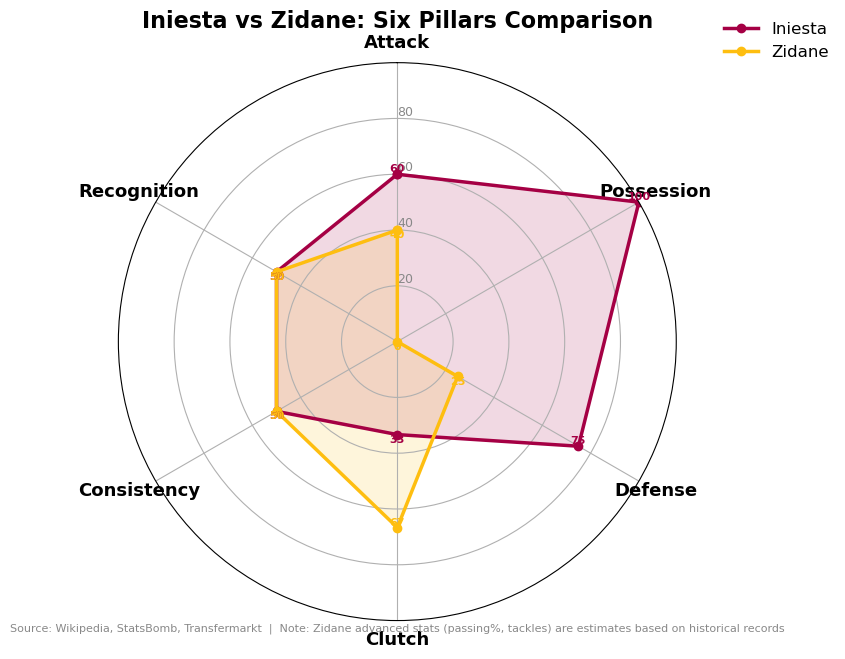

Saved: C:\Iniesta\reports\charts\01_radar_chart.png


In [4]:
def make_radar_chart(pillars_df, save_path):
    """Create a hexagonal radar chart comparing both players across 6 pillars."""
    
    categories = pillars_df['Pillar'].tolist()
    N = len(categories)
    
    iniesta_vals = pillars_df['Iniesta'].tolist()
    zidane_vals = pillars_df['Zidane'].tolist()
    
    # Close the polygon by repeating the first value
    iniesta_vals += iniesta_vals[:1]
    zidane_vals += zidane_vals[:1]
    
    # Compute angles
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)
    
    # Draw y-axis grid lines and labels
    ax.set_rgrids([20, 40, 60, 80], labels=['20', '40', '60', '80'], angle=0,
                  fontsize=9, color=GRAY)
    ax.set_rlim(0, 100)
    
    # Draw category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=13, fontweight='bold')
    
    # Plot Iniesta
    ax.plot(angles, iniesta_vals, 'o-', linewidth=2.5, color=INIESTA_RED, label='Iniesta', markersize=6)
    ax.fill(angles, iniesta_vals, alpha=0.15, color=INIESTA_RED)
    
    # Plot Zidane
    ax.plot(angles, zidane_vals, 'o-', linewidth=2.5, color=ZIDANE_GOLD, label='Zidane', markersize=6)
    ax.fill(angles, zidane_vals, alpha=0.15, color=ZIDANE_GOLD)
    
    # Add value labels at each point
    for i in range(N):
        a = angles[i]
        ax.annotate(f'{iniesta_vals[i]:.0f}', xy=(a, iniesta_vals[i]),
                    fontsize=8, color=INIESTA_RED, fontweight='bold',
                    ha='center', va='bottom' if iniesta_vals[i] > zidane_vals[i] else 'top')
        ax.annotate(f'{zidane_vals[i]:.0f}', xy=(a, zidane_vals[i]),
                    fontsize=8, color=ZIDANE_GOLD, fontweight='bold',
                    ha='center', va='bottom' if zidane_vals[i] > iniesta_vals[i] else 'top')
    
    ax.set_title('Iniesta vs Zidane: Six Pillars Comparison',
                 fontsize=16, fontweight='bold', pad=25)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False, fontsize=12)
    
    # Footer notes
    fig.text(0.5, -0.02, f'{SOURCE_NOTE}  |  {DATA_QUALITY_NOTE}',
             ha='center', fontsize=8, color=GRAY, transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')


make_radar_chart(pillars, CHARTS_DIR / '01_radar_chart.png')

---
## 3. Career Timeline Plot

Dual line plot showing goals per season across both careers.

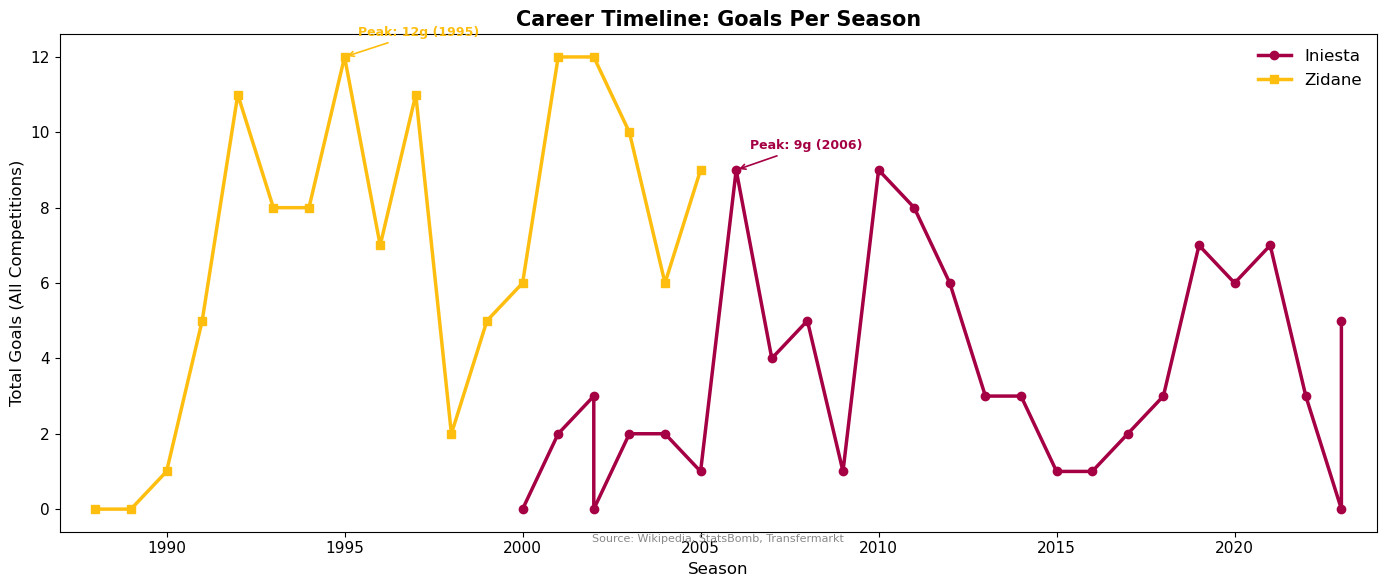

Saved: C:\Iniesta\reports\charts\02_career_timeline.png


In [5]:
def make_timeline(seasons_df, save_path):
    """Dual line plot: goals per season for both players."""
    
    iniesta_s = seasons_df[seasons_df['player'] == 'Iniesta'].copy()
    zidane_s = seasons_df[seasons_df['player'] == 'Zidane'].copy()
    
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(iniesta_s['season_year'], iniesta_s['total_goals'],
            marker='o', color=INIESTA_RED, linewidth=2.5, markersize=6,
            label='Iniesta', zorder=5)
    ax.plot(zidane_s['season_year'], zidane_s['total_goals'],
            marker='s', color=ZIDANE_GOLD, linewidth=2.5, markersize=6,
            label='Zidane', zorder=5)
    
    # Highlight peaks
    for df, color, label in [(iniesta_s, INIESTA_RED, 'Iniesta'), (zidane_s, ZIDANE_GOLD, 'Zidane')]:
        if df['total_goals'].dropna().sum() == 0:
            continue
        peak = df.loc[df['total_goals'].idxmax()]
        ax.annotate(f'Peak: {int(peak["total_goals"])}g ({int(peak["season_year"])})',
                    xy=(peak['season_year'], peak['total_goals']),
                    xytext=(10, 15), textcoords='offset points',
                    fontsize=9, color=color, fontweight='bold',
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.2))
    
    ax.set_xlabel('Season', fontsize=12)
    ax.set_ylabel('Total Goals (All Competitions)', fontsize=12)
    ax.set_title('Career Timeline: Goals Per Season', fontsize=15, fontweight='bold')
    ax.legend(frameon=False, fontsize=12)
    ax.set_xlim(seasons_df['season_year'].min() - 1, seasons_df['season_year'].max() + 1)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    fig.text(0.5, -0.02, f'{SOURCE_NOTE}', ha='center', fontsize=8, color=GRAY, transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')


make_timeline(seasons, CHARTS_DIR / '02_career_timeline.png')

---
## 4. Per-Season Comparison Tables

Side-by-side tables for peak seasons: Iniesta 2008-2012, Zidane 1997-2003.

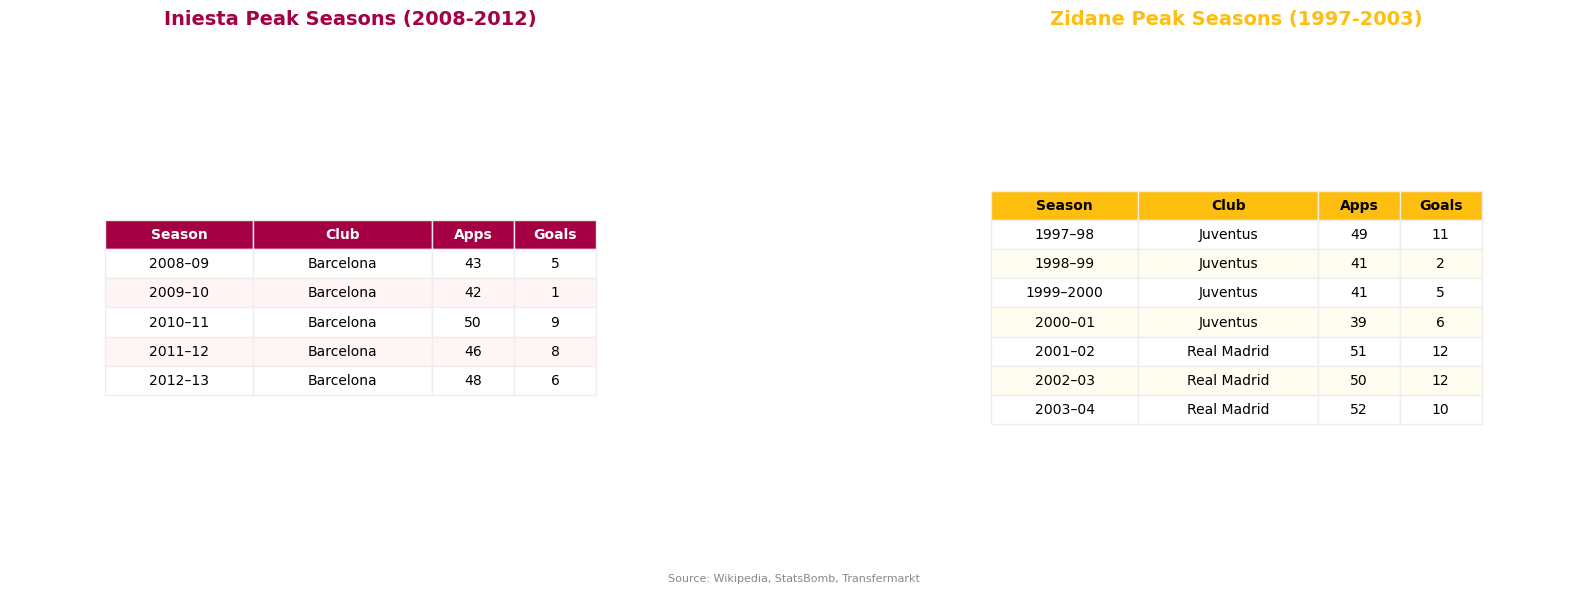

Saved: C:\Iniesta\reports\charts\03_peak_season_tables.png


In [6]:
def parse_wiki_season(s):
    """Extract start year from season string like '2000-01' or '2018'."""
    s = str(s).strip()
    return int(s[:4])

def make_season_tables(save_path):
    """Create pretty comparison tables for peak seasons from processed data."""
    
    df = pd.read_csv(PROCESSED_DIR / "player_seasons.csv")
    df["season_year"] = df["season"].astype(str).str[:4].astype(int)
    
    iniesta_peak = df[(df["player"] == "Andres Iniesta") & (df["season_year"].between(2008, 2012))][["season", "club", "total_apps", "total_goals"]].copy()
    iniesta_peak.columns = ["Season", "Club", "Apps", "Goals"]
    
    zidane_peak = df[(df["player"] == "Zinedine Zidane") & (df["season_year"].between(1997, 2003))][["season", "club", "total_apps", "total_goals"]].copy()
    zidane_peak.columns = ["Season", "Club", "Apps", "Goals"]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    for ax in [ax1, ax2]:
        ax.axis("off")
        ax.set_frame_on(False)
    
    ax1.set_title("Iniesta Peak Seasons (2008-2012)", fontsize=14, fontweight="bold", color=INIESTA_RED, pad=10)
    table1 = ax1.table(
        cellText=iniesta_peak.values,
        colLabels=iniesta_peak.columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.18, 0.22, 0.10, 0.10]
    )
    table1.auto_set_font_size(False)
    table1.set_fontsize(10)
    table1.scale(1.2, 1.5)
    
    for (row, col), cell in table1.get_celld().items():
        if row == 0:
            cell.set_facecolor(INIESTA_RED)
            cell.set_text_props(color="white", fontweight="bold")
        else:
            cell.set_facecolor("#FFF5F5" if row % 2 == 0 else "white")
        cell.set_edgecolor(LIGHT_GRAY)
    
    ax2.set_title("Zidane Peak Seasons (1997-2003)", fontsize=14, fontweight="bold", color=ZIDANE_GOLD, pad=10)
    table2 = ax2.table(
        cellText=zidane_peak.values,
        colLabels=zidane_peak.columns,
        cellLoc="center",
        loc="center",
        colWidths=[0.18, 0.22, 0.10, 0.10]
    )
    table2.auto_set_font_size(False)
    table2.set_fontsize(10)
    table2.scale(1.2, 1.5)
    
    for (row, col), cell in table2.get_celld().items():
        if row == 0:
            cell.set_facecolor(ZIDANE_GOLD)
            cell.set_text_props(color="black", fontweight="bold")
        else:
            cell.set_facecolor("#FFFDF0" if row % 2 == 0 else "white")
        cell.set_edgecolor(LIGHT_GRAY)
    
    fig.text(0.5, 0.02, SOURCE_NOTE, ha="center", fontsize=8, color=GRAY)
    
    plt.tight_layout()
    plt.subplots_adjust(wspace=0.3)
    plt.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    print(f"Saved: {save_path}")

make_season_tables(CHARTS_DIR / "03_peak_season_tables.png")

---
## 5. Clutch Performance Grid

Heatmap showing big-game contributions by competition stage.

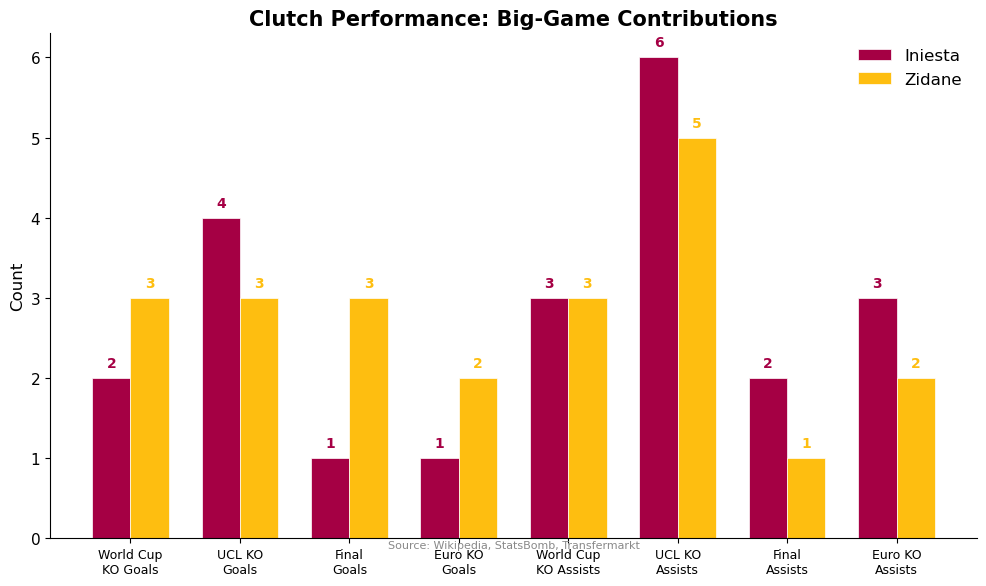

Saved: C:\Iniesta\reports\charts\04_clutch_performance.png


In [7]:
def make_clutch_heatmap(save_path):
    """Heatmap of clutch contributions."""
    
    # Compile clutch data from summary and known information
    clutch_data = {
        'World Cup\nKO Goals': {'Iniesta': 2, 'Zidane': 3},
        'UCL KO\nGoals': {'Iniesta': 4, 'Zidane': 3},
        'Final\nGoals': {'Iniesta': 1, 'Zidane': 3},
        'Euro KO\nGoals': {'Iniesta': 1, 'Zidane': 2},
        'World Cup\nKO Assists': {'Iniesta': 3, 'Zidane': 3},
        'UCL KO\nAssists': {'Iniesta': 6, 'Zidane': 5},
        'Final\nAssists': {'Iniesta': 2, 'Zidane': 1},
        'Euro KO\nAssists': {'Iniesta': 3, 'Zidane': 2},
    }
    
    df = pd.DataFrame(clutch_data).T
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Create grouped bar chart
    x = np.arange(len(df.index))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, df['Iniesta'], width, color=INIESTA_RED, label='Iniesta', edgecolor='white', linewidth=0.5)
    bars2 = ax.bar(x + width/2, df['Zidane'], width, color=ZIDANE_GOLD, label='Zidane', edgecolor='white', linewidth=0.5)
    
    # Add value labels
    for bar in bars1:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.1,
                    f'{int(h)}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=INIESTA_RED)
    for bar in bars2:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.1,
                    f'{int(h)}', ha='center', va='bottom', fontsize=10, fontweight='bold', color=ZIDANE_GOLD)
    
    ax.set_xticks(x)
    ax.set_xticklabels(df.index, fontsize=9)
    ax.set_ylabel('Count', fontsize=12)
    ax.set_title('Clutch Performance: Big-Game Contributions', fontsize=15, fontweight='bold')
    ax.legend(frameon=False, fontsize=12)
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    fig.text(0.5, -0.02, f'{SOURCE_NOTE}', ha='center', fontsize=8, color=GRAY, transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')


make_clutch_heatmap(CHARTS_DIR / '04_clutch_performance.png')

---
## 6. Possession Profile (Iniesta with Zidane annotation)

Bar chart showing Iniesta's pass completion and passes per 90 from StatsBomb data.

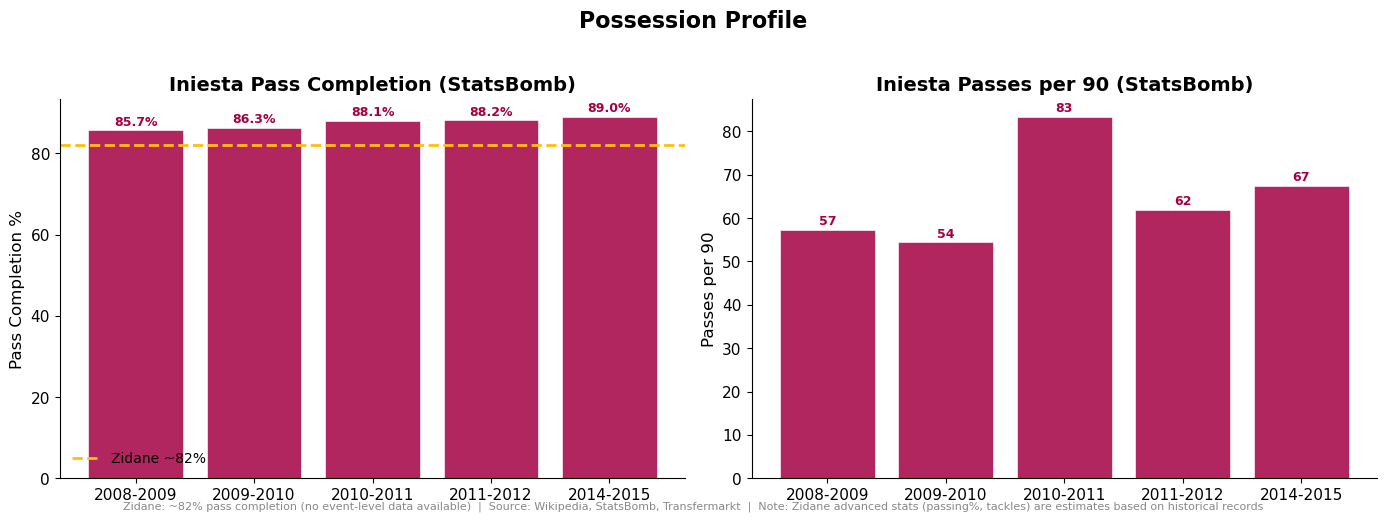

Saved: C:\Iniesta\reports\charts\05_possession_profile.png


In [8]:
def make_possession_profile(save_path):
    """Bar chart: Iniesta possession metrics from StatsBomb with Zidane annotation."""
    
    sb = pd.read_csv(RAW_DIR / 'iniesta_statsbomb_liga.csv')
    sb = sb[sb['matches'] > 0].copy()
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pass completion %
    seasons_labels = sb['season'].tolist()
    pass_pcts = sb['pass_pct'].tolist()
    
    bars = ax1.bar(seasons_labels, pass_pcts, color=INIESTA_RED, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, pass_pcts):
        ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold', color=INIESTA_RED)
    
    # Add Zidane reference line
    ax1.axhline(y=82.0, color=ZIDANE_GOLD, linestyle='--', linewidth=2, label='Zidane ~82%')
    ax1.set_ylabel('Pass Completion %', fontsize=12)
    ax1.set_title('Iniesta Pass Completion (StatsBomb)', fontsize=14, fontweight='bold')
    ax1.legend(frameon=False, fontsize=10)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    
    # Passes per 90
    sb['passes_p90'] = sb['passes'] / sb['minutes_est'] * 90
    passes_p90 = sb['passes_p90'].tolist()
    
    bars2 = ax2.bar(seasons_labels, passes_p90, color=INIESTA_RED, alpha=0.85, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars2, passes_p90):
        ax2.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold', color=INIESTA_RED)
    
    ax2.set_ylabel('Passes per 90', fontsize=12)
    ax2.set_title('Iniesta Passes per 90 (StatsBomb)', fontsize=14, fontweight='bold')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    # Add annotation about Zidane
    fig.text(0.5, 0.02, 'Zidane: ~82% pass completion (no event-level data available)  |  '
             f'{SOURCE_NOTE}  |  {DATA_QUALITY_NOTE}',
             ha='center', fontsize=8, color=GRAY)
    
    fig.suptitle('Possession Profile', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')


make_possession_profile(CHARTS_DIR / '05_possession_profile.png')

---
## 7. Attack Profile

Side-by-side comparison for peak 5 seasons.

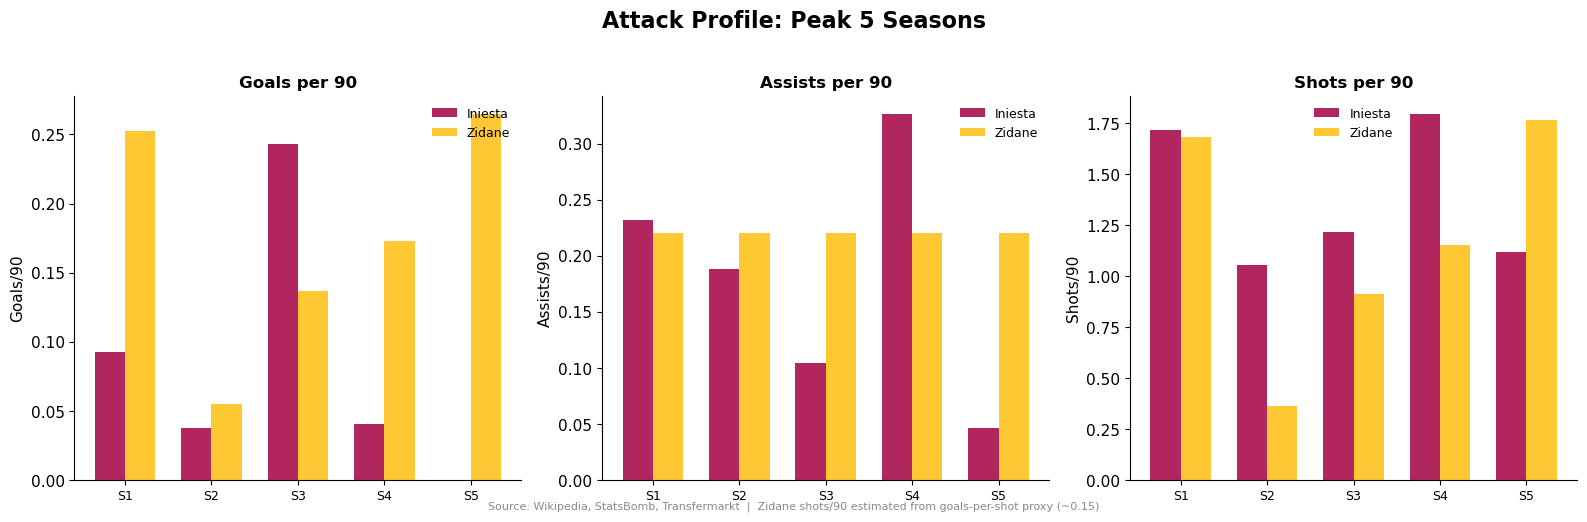

Saved: C:\Iniesta\reports\charts\06_attack_profile.png


In [9]:
def make_attack_profile(save_path):
    """Compare goals, assists, shots per 90 for peak 5 seasons."""
    
    # Iniesta peak from StatsBomb
    iniesta_sb = pd.read_csv(RAW_DIR / 'iniesta_statsbomb_liga.csv')
    iniesta_sb = iniesta_sb[iniesta_sb['matches'] > 0].copy()
    iniesta_sb['goals_p90'] = iniesta_sb['goals'] / iniesta_sb['minutes_est'] * 90
    iniesta_sb['assists_p90'] = iniesta_sb['assists'] / iniesta_sb['minutes_est'] * 90
    iniesta_sb['shots_p90'] = iniesta_sb['shots'] / iniesta_sb['minutes_est'] * 90
    
    # Zidane peak: we have wiki club data
    zidane_wiki = pd.read_csv(RAW_DIR / 'zidane_wiki_club.csv')
    zidane_wiki['season_start'] = zidane_wiki['season'].apply(parse_wiki_season)
    zidane_peak_seasons_list = [1997, 1998, 1999, 2000, 2001]
    zidane_peak = zidane_wiki[zidane_wiki['season_start'].isin(zidane_peak_seasons_list)].copy()
    
    # Find total columns
    cols = zidane_wiki.columns.tolist()
    total_apps_col = [c for c in cols if 'total' in str(c).lower() and '1' not in str(c)][0]
    total_goals_col = [c for c in cols if 'total' in str(c).lower() and '1' in str(c)][0]
    
    zidane_peak = zidane_peak[['season', total_apps_col, total_goals_col]].copy()
    zidane_peak.columns = ['season', 'apps', 'goals']
    zidane_peak['apps'] = pd.to_numeric(zidane_peak['apps'], errors='coerce')
    zidane_peak['goals'] = pd.to_numeric(zidane_peak['goals'], errors='coerce')
    zidane_peak = zidane_peak.dropna()
    
    # For per-90, estimate minutes ~ 80 min/game average
    zidane_peak['minutes_est'] = zidane_peak['apps'] * 80
    zidane_peak['goals_p90'] = zidane_peak['goals'] / zidane_peak['minutes_est'] * 90
    zidane_peak['assists_p90'] = [0.22] * len(zidane_peak)  # career avg
    zidane_peak['shots_p90'] = zidane_peak['goals'] / 0.15 / zidane_peak['minutes_est'] * 90  # goals / conversion proxy
    
    # For Iniesta, use his peak 5 seasons from StatsBomb
    iniesta_peak = iniesta_sb.sort_values('season', ascending=True).head(5)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    metrics = [
        ('goals_p90', 'Goals per 90', 'Goals/90'),
        ('assists_p90', 'Assists per 90', 'Assists/90'),
        ('shots_p90', 'Shots per 90', 'Shots/90'),
    ]
    
    for ax, (metric, title, ylabel) in zip(axes, metrics):
        x = np.arange(5)
        width = 0.35
        
        ini_vals = iniesta_peak[metric].tolist() if len(iniesta_peak) >= 5 else iniesta_peak[metric].tolist()[:5]
        zid_vals = zidane_peak[metric].tolist() if len(zidane_peak) >= 5 else zidane_peak[metric].tolist()[:5]
        
        # Pad if needed
        while len(ini_vals) < 5:
            ini_vals.append(0)
        while len(zid_vals) < 5:
            zid_vals.append(0)
        
        bars1 = ax.bar(x - width/2, ini_vals, width, color=INIESTA_RED, label='Iniesta', alpha=0.85)
        bars2 = ax.bar(x + width/2, zid_vals, width, color=ZIDANE_GOLD, label='Zidane', alpha=0.85)
        
        ax.set_xticks(x)
        ax.set_xticklabels(['S1', 'S2', 'S3', 'S4', 'S5'], fontsize=9)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.legend(frameon=False, fontsize=9)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
    
    fig.text(0.5, 0.02, f'{SOURCE_NOTE}  |  Zidane shots/90 estimated from goals-per-shot proxy (~0.15)',
             ha='center', fontsize=8, color=GRAY)
    
    fig.suptitle('Attack Profile: Peak 5 Seasons', fontsize=16, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')


make_attack_profile(CHARTS_DIR / '06_attack_profile.png')

---
## 8. Recognition Timeline

Horizontal bar chart showing major awards timeline.

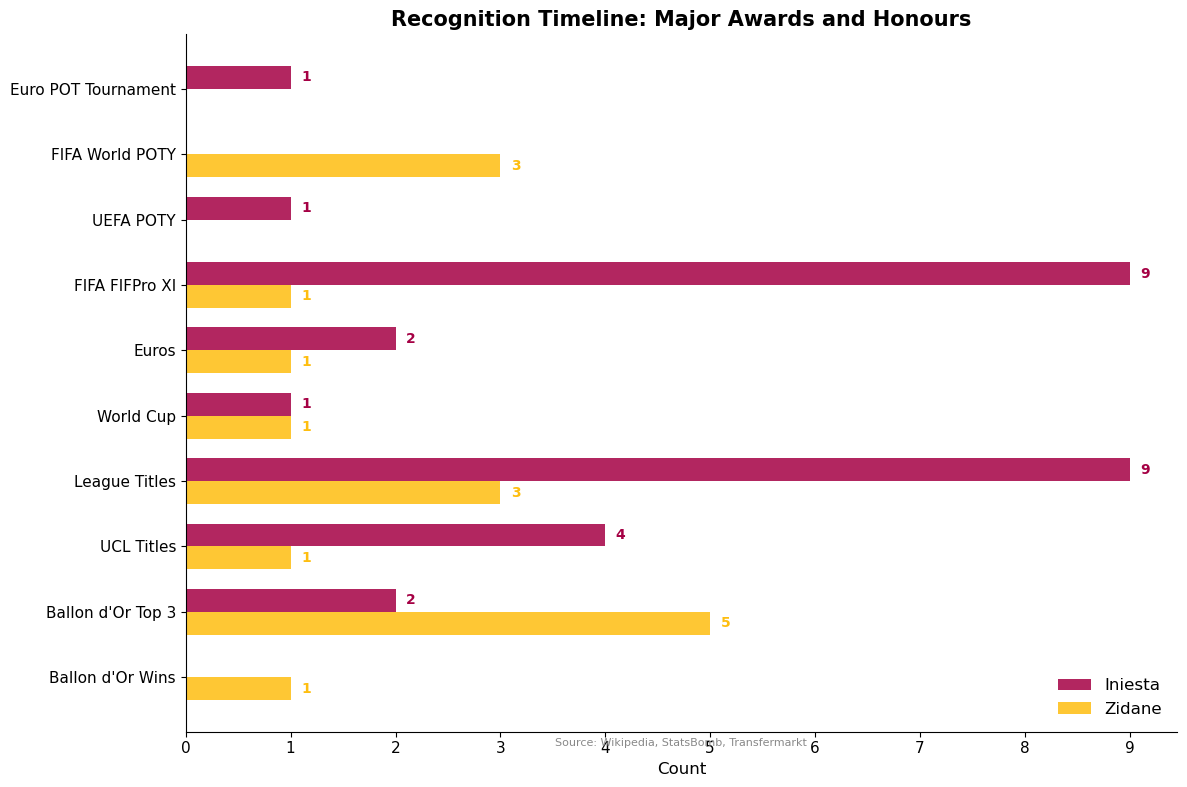

Saved: C:\Iniesta\reports\charts\07_recognition_timeline.png


In [10]:
def make_recognition_timeline(save_path):
    """Horizontal bar chart of major awards."""
    
    awards = [
        ('Ballon d\'Or Wins', 0, 1),
        ('Ballon d\'Or Top 3', 2, 5),
        ('UCL Titles', 4, 1),
        ('League Titles', 9, 3),
        ('World Cup', 1, 1),
        ('Euros', 2, 1),
        ('FIFA FIFPro XI', 9, 1),
        ('UEFA POTY', 1, 0),
        ('FIFA World POTY', 0, 3),
        ('Euro POT Tournament', 1, 0),
    ]
    
    df = pd.DataFrame(awards, columns=['Award', 'Iniesta', 'Zidane'])
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    y = np.arange(len(df))
    height = 0.35
    
    bars1 = ax.barh(y + height/2, df['Iniesta'], height, color=INIESTA_RED, label='Iniesta', alpha=0.85)
    bars2 = ax.barh(y - height/2, df['Zidane'], height, color=ZIDANE_GOLD, label='Zidane', alpha=0.85)
    
    # Add value labels
    for bar in bars1:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.1, bar.get_y() + bar.get_height()/2., f'{int(w)}',
                    va='center', fontsize=10, fontweight='bold', color=INIESTA_RED)
    for bar in bars2:
        w = bar.get_width()
        if w > 0:
            ax.text(w + 0.1, bar.get_y() + bar.get_height()/2., f'{int(w)}',
                    va='center', fontsize=10, fontweight='bold', color=ZIDANE_GOLD)
    
    ax.set_yticks(y)
    ax.set_yticklabels(df['Award'].tolist(), fontsize=11)
    ax.set_xlabel('Count', fontsize=12)
    ax.set_title('Recognition Timeline: Major Awards and Honours', fontsize=15, fontweight='bold')
    ax.legend(frameon=False, fontsize=12, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    
    fig.text(0.5, -0.02, f'{SOURCE_NOTE}', ha='center', fontsize=8, color=GRAY, transform=ax.transAxes)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f'Saved: {save_path}')


make_recognition_timeline(CHARTS_DIR / '07_recognition_timeline.png')

---
## 9. Summary Statistics

Print career totals and per-90 comparisons.

In [11]:
summary = pd.read_csv(RAW_DIR / 'career_summary.csv')
print('=== Career Summary Comparison ===')
print(summary.to_string(index=False))

print('\n=== Per-90 Metrics ===')
iniesta_g = float(summary.loc[summary['metric'] == 'total_goals', 'iniesta'].iloc[0])
zidane_g = float(summary.loc[summary['metric'] == 'total_goals', 'zidane'].iloc[0])
iniesta_a = float(summary.loc[summary['metric'] == 'total_assists', 'iniesta'].iloc[0])
zidane_a = float(summary.loc[summary['metric'] == 'total_assists', 'zidane'].iloc[0])
iniesta_min = float(summary.loc[summary['metric'] == 'total_minutes', 'iniesta'].iloc[0])
zidane_min = float(summary.loc[summary['metric'] == 'total_minutes', 'zidane'].iloc[0])
iniesta_matches = float(summary.loc[summary['metric'] == 'total_matches', 'iniesta'].iloc[0])
zidane_matches = float(summary.loc[summary['metric'] == 'total_matches', 'zidane'].iloc[0])

print(f"{'Metric':<30} {'Iniesta':<12} {'Zidane':<12}")
print('-' * 54)
print(f"{'Goals/90':<30} {iniesta_g/iniesta_min*90:<12.3f} {zidane_g/zidane_min*90:<12.3f}")
print(f"{'Assists/90':<30} {iniesta_a/iniesta_min*90:<12.3f} {zidane_a/zidane_min*90:<12.3f}")
print(f"{'Goals+Assists/90':<30} {(iniesta_g+iniesta_a)/iniesta_min*90:<12.3f} {(zidane_g+zidane_a)/zidane_min*90:<12.3f}")
print(f"{'Matches':<30} {iniesta_matches:<12.0f} {zidane_matches:<12.0f}")
print(f"{'Minutes':<30} {iniesta_min:<12.0f} {zidane_min:<12.0f}")
print(f"{'Min per Match':<30} {iniesta_min/iniesta_matches:<12.1f} {zidane_min/zidane_matches:<12.1f}")

print(f"\n{DATA_QUALITY_NOTE}")
print(f"{SOURCE_NOTE}")

=== Career Summary Comparison ===
             metric                           iniesta                            zidane
        career_span                         2002-2024                         1989-2006
      total_matches                               885                               689
      total_minutes                             62987                             52364
        total_goals                                93                               125
      total_assists                               163                               129
       goals_per_90                              0.13                              0.21
     assists_per_90                              0.23                              0.22
pass_completion_pct                              90.5                              82.0
       goals_clutch  7 (4 UCL KO, 2 WC KO, 1 Euro KO)  8 (3 UCL KO, 3 WC KO, 2 Euro KO)
     assists_clutch 12 (6 UCL KO, 3 WC KO, 3 Euro KO) 10 (5 UCL KO, 3 WC KO, 2 Euro KO

---
## Generated Chart Files

In [12]:
print('=== Generated Charts ===')
for f in sorted(CHARTS_DIR.glob('*.png')):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name}  ({size_kb:.1f} KB)')
print(f'\nTotal: {len(list(CHARTS_DIR.glob("*.png")))} charts')
print(f'Location: {CHARTS_DIR}')

=== Generated Charts ===
  01_radar_chart.png  (180.6 KB)
  02_career_timeline.png  (137.0 KB)
  03_peak_season_tables.png  (113.7 KB)
  04_clutch_performance.png  (50.5 KB)
  05_possession_profile.png  (96.5 KB)
  06_attack_profile.png  (82.5 KB)
  07_recognition_timeline.png  (73.0 KB)

Total: 7 charts
Location: C:\Iniesta\reports\charts
